In [1]:
import sys
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
from galfits import images as IM
import pickle
from astropy.stats import sigma_clipped_stats
from astropy.visualization.mpl_normalize import simple_norm
from astropy.table import Table, Column
import matplotlib.pyplot as plt
from galfits import gsutils
from galfits import sed_interp as SI
from galfits import galaxy as GAL
import numpy as np
import time
import jax.numpy as jnp
import wget,shutil
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM,z_at_value
from scipy.ndimage import zoom
from astropy.io import fits, ascii
from matplotlib import patches 
from astropy.wcs import WCS
from skimage.transform import resize
from astropy.visualization import make_lupton_rgb
plt.style.use("classic")
plt.rc('font',family='Times New Roman')


Could not import regions, which is required for some of the functionalities of this module.


In [3]:
name = 'GNZ7Q'
priorpath = './result/AGNfit.prior'
config_file_path='./result/finalfit.lyric'
workplace = './result/final/'

#Myfitter,targ,fs = gsutils.read_config_file(config_file_path,workplace,priorpath=priorpath,vectorize=False)
smfile = ascii.read(workplace+'{0}.gssummary'.format(name))
age = [0.0, 0.02, 0.04768734, 0.06891159, 0.1, 0.14390325, 0.2079504, 0.30050308, 0.43424826, 0.5512227498587026] 
name = 'total'
logM = smfile['best_value'][smfile['pname']=='logM_{0}'.format(name)][0]
f_cont = []
for loop in range(9):
    f_cont.append(smfile['best_value'][smfile['pname']=='{0}_f_cont_bin{1}'.format(name,loop+1)][0])
f_cont = np.array(f_cont)
logSFR_total = SI.f_cont_to_logSFR(f_cont, logM, age, SFH = 'bins')
name = 'comp'
logM = smfile['best_value'][smfile['pname']=='logM_{0}'.format(name)][0]
f_cont = []
for loop in range(9):
    f_cont.append(smfile['best_value'][smfile['pname']=='{0}_f_cont_bin{1}'.format(name,loop+1)][0])
f_cont = np.array(f_cont)
logSFR_comp = SI.f_cont_to_logSFR(f_cont, logM, age, SFH = 'bins')
logSFR = np.log10(10**(logSFR_total) + 10**(logSFR_comp))
print ("total logSFR: ", logSFR)

total logSFR:  2.2356148


In [5]:
10**0.2

1.5848931924611136

INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  1.1387e+21
nircam_f182m band image unit to counts rate is  12.045215
nircam_f182m std 0.006694423966109753
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  4.4562e+20
nircam_f115w band image unit to counts rate is  4.7137866
nircam_f115w std 0.008355463854968548
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  6.4857e+21
nircam_f444w band image unit to counts rate is  68.606
nircam_f444w std 0.02270454913377762
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  2.7228e+20
nircam_f090w band image unit to counts rate is  2.880189
nircam_f090

Set DATE-AVG to '2025-02-19T21:00:11.194' from MJD-AVG.
Set DATE-END to '2025-02-27T04:55:18.538' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    15.777470 from OBSGEO-[XYZ].
Set OBSGEO-H to 1598346142.541 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-02-20T14:12:48.347' from MJD-AVG.
Set DATE-END to '2025-02-27T04:32:47.115' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    21.446560 from OBSGEO-[XYZ].
Set OBSGEO-H to 1432517049.518 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


nircam_f356w std 0.021375644952058792
No energy balances assigned


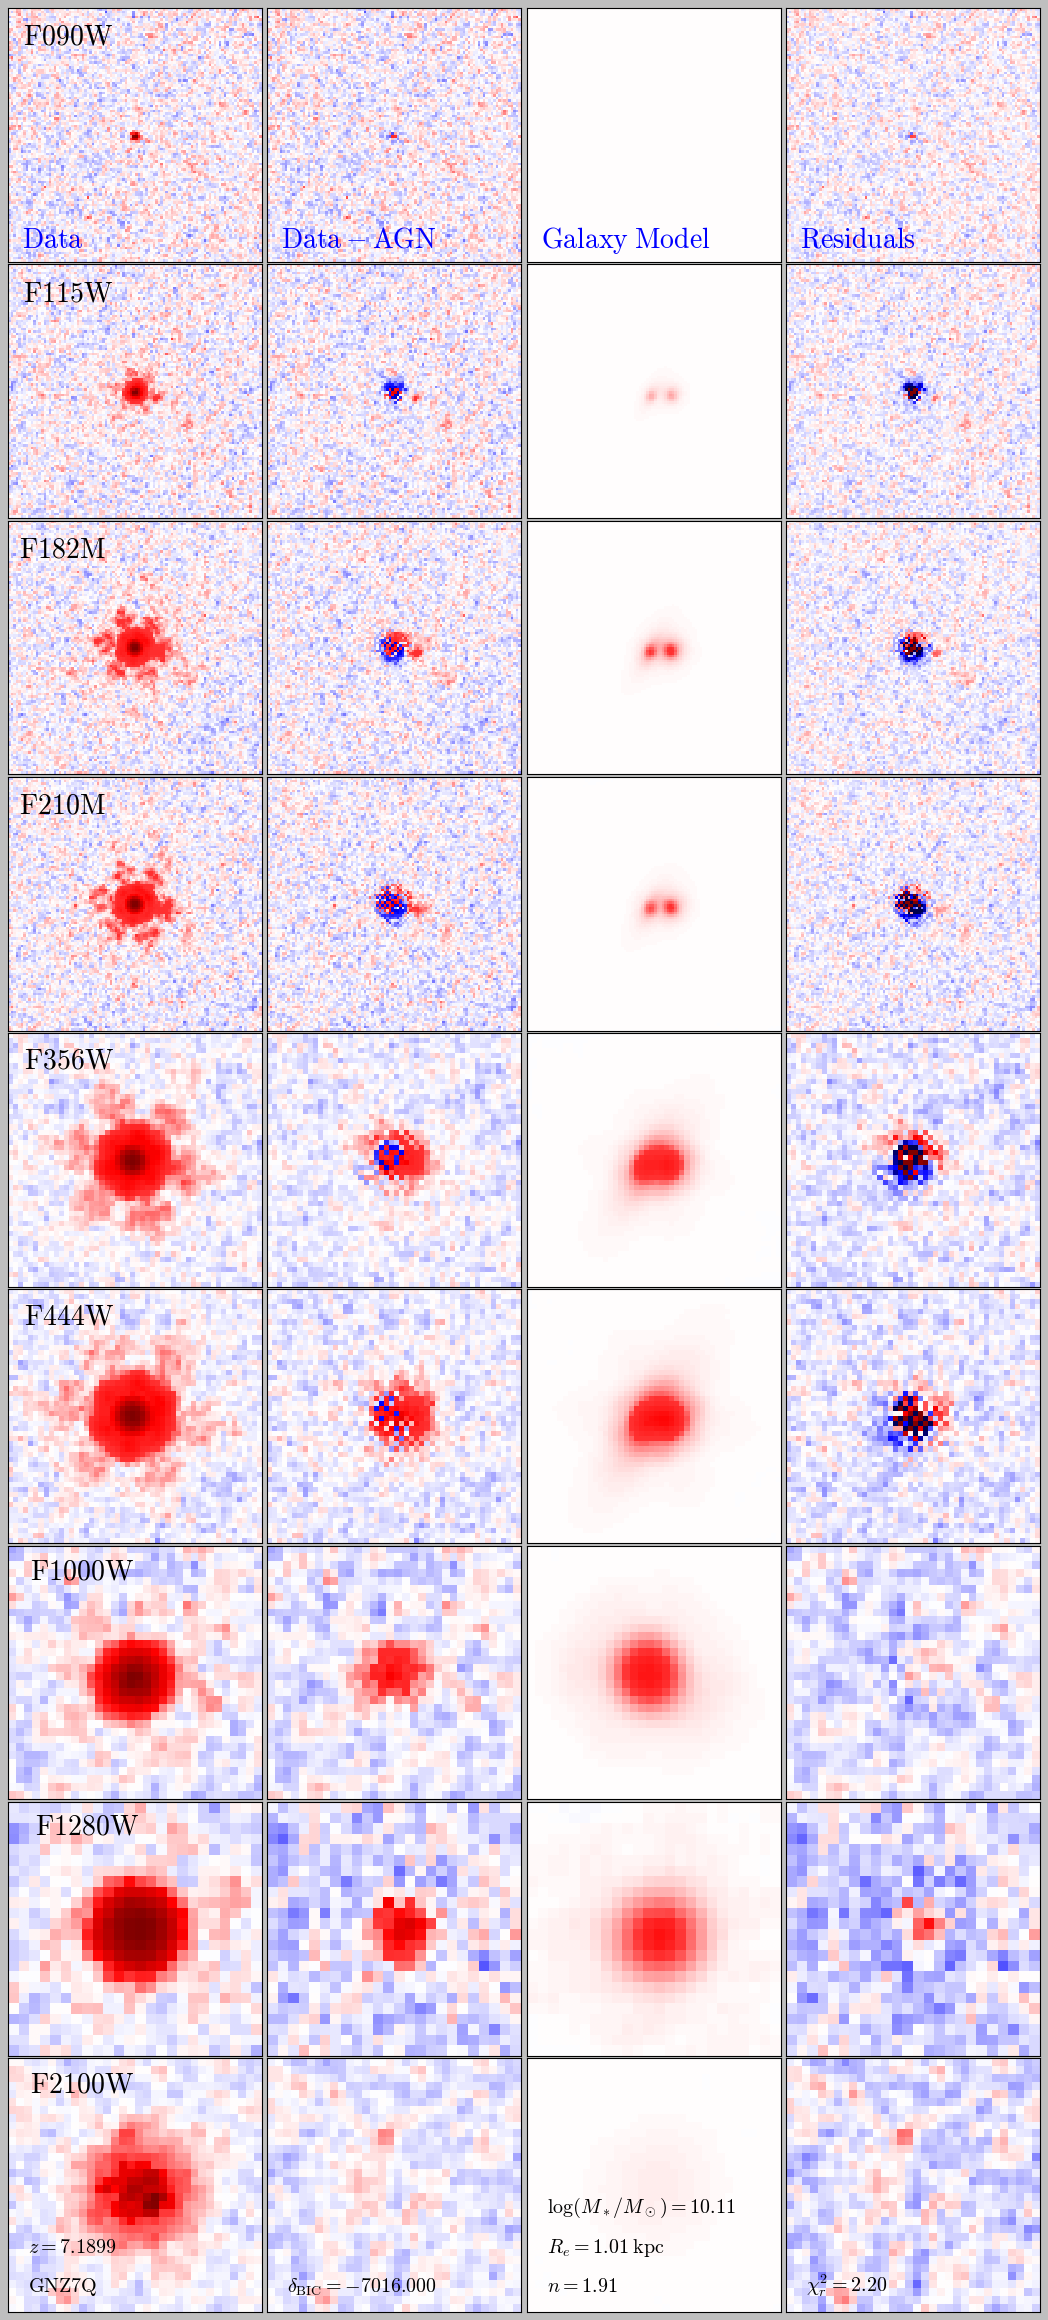

In [4]:
name = 'GNZ7Q'
priorpath = './result/AGNfit.prior'
config_file_path='./result/finalfit.lyric'
workplace = './result/final/'

Myfitter,targ,fs = gsutils.read_config_file(config_file_path,workplace,priorpath=priorpath,vectorize=False)
smfile = ascii.read(workplace+'{0}.gssummary'.format(name))
for loopx in range(len(smfile)):
    Myfitter.lmParameters[smfile['pname'][loopx]].set(value=smfile['best_value'][loopx], min=smfile['best_value'][loopx]-0.1,max=smfile['best_value'][loopx]+0.1)
Myfitter.loose_fix_pars()
logM = 10.11
re = 0.1913*5.2618
n = 1.91
z = 7.1899
dBIC = -7016
chisq = 2.20
cosmo = FlatLambdaCDM(H0=67.8 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.308)
d=cosmo.angular_diameter_distance(z)
dc=d.to(u.cm)
dis=dc.value
scale = d.to(u.kpc).value*np.pi/180/3600

images = []
models = []
agns = []
galaxies = []
gmodel = []
residuals = []
bands = []
MASK = []
pltwave, Sedcomp, Sedlabel, z0 = Myfitter.cal_model_image()
nimage = 9
for i in range(nimage):
    im = Myfitter.GSdata.get_image(i)
    sky_mean, sky_median, sky_std = sigma_clipped_stats(im.cut_image, sigma=3.0, maxiters=5)
    im.cut_image = im.cut_image - sky_median
    images.append(im.cut_image)
    models.append(im.model_image)
    residuals.append((im.cut_image-im.model_image)/im.cut_sigma_image)
pltwave, Sedcomp, Sedlabel, z0 = Myfitter.cal_model_image(ndisagn=True)  
for i in range(nimage):
    im = Myfitter.GSdata.get_image(i)
    MASK.append(im.cut_mask_image)
    galaxies.append(im.model_image+residuals[i]*im.cut_sigma_image)
    gmodel.append(im.model_image)
    agns.append(models[i]-im.model_image)
Band = ['f090w','f115w','f182m','f210m','f356w','f444w', 'f1000w', 'f1280w', 'f2100w']
blabels = [r'$\rm \; F090W$', r'$\rm  \; F115W$', r'$\rm  \; F182M$', r'$\rm  \; F210M$', r'$\rm  \; F356W$', r'$\rm  \; F444W$', r'$\rm  \; F1000W$', r'$\rm  \; F1280W$', r'$\rm  \; F2100W$']
nrows = nimage
ncols = 4
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16.7,4*nrows),squeeze=True)
plt.subplots_adjust(hspace=0.01, wspace=0.01) 
ax = ax.ravel()
for i in range(nrows):
    
    sky_mean, sky_median, sky_std = sigma_clipped_stats(images[i], sigma=3.0, maxiters=5)
    immin = 5*sky_std
    #immax = 500*sky_std
    immax = jnp.max(images[i])
    frac = 0.4
    if i == 0:
        ax[4*i].imshow(gsutils.normimg(images[i], immin, immax,frac=frac), cmap='seismic', origin='lower', vmin=-1, vmax=1,interpolation='nearest')
        ax[4*i].imshow(MASK[1], cmap='Blues', origin='lower', vmin=0, vmax=1,alpha=0.5*MASK[1])
        ax[4*i+1].imshow(gsutils.normimg(galaxies[i], immin, immax,frac=frac), cmap='seismic', origin='lower',vmin=-1, vmax=1,interpolation='nearest')
        ax[4*i+1].imshow(MASK[1], cmap='Blues', origin='lower', vmin=0, vmax=1,alpha=0.5*MASK[1])
        ax[4*i+2].imshow(gsutils.normimg(gmodel[i], immin, immax,frac=frac), cmap='seismic', origin='lower', vmin=-1, vmax=1,interpolation='nearest')
        ax[4*i+3].imshow(0.07*residuals[i], cmap='seismic', origin='lower', vmin=-1, vmax=1,interpolation='nearest')
        ax[4*i+3].imshow(MASK[1], cmap='Blues', origin='lower', vmin=0, vmax=1,alpha=0.5*MASK[1])
    else:
        ax[4*i].imshow(gsutils.normimg(images[i], immin, immax,frac=frac), cmap='seismic', origin='lower', vmin=-1, vmax=1,interpolation='nearest')
        ax[4*i].imshow(MASK[i], cmap='Blues', origin='lower', vmin=0, vmax=1,alpha=0.5*MASK[i])
        ax[4*i+1].imshow(gsutils.normimg(galaxies[i], immin, immax,frac=frac), cmap='seismic', origin='lower',vmin=-1, vmax=1,interpolation='nearest')
        ax[4*i+1].imshow(MASK[i], cmap='Blues', origin='lower', vmin=0, vmax=1,alpha=0.5*MASK[i])
        ax[4*i+2].imshow(gsutils.normimg(gmodel[i], immin, immax,frac=frac), cmap='seismic', origin='lower', vmin=-1, vmax=1,interpolation='nearest')
        ax[4*i+3].imshow(0.07*residuals[i], cmap='seismic', origin='lower', vmin=-1, vmax=1,interpolation='nearest')
        ax[4*i+3].imshow(MASK[i], cmap='Blues', origin='lower', vmin=0, vmax=1,alpha=0.5*MASK[i])

    ny,nx = images[i].shape
    if i > 1:
        ax[4*i].text(1.5,0.85*ny, blabels[i], size = 25, color = 'k', weight = "light" )
    else:
        ax[4*i].text(3,0.85*ny, blabels[i], size = 25, color = 'k', weight = "light" )
    ax[4*i].set_xticks([])
    ax[4*i].set_yticks([])
    ax[4*i+1].set_xticks([])
    ax[4*i+1].set_yticks([])
    ax[4*i+2].set_xticks([])
    ax[4*i+2].set_yticks([])
    ax[4*i+3].set_xticks([])
    ax[4*i+3].set_yticks([])

size1 = Myfitter.GSdata.get_image('nircam_f090w').cut_image.shape[0]
size2 = 2*Myfitter.GSdata.get_image('nircam_f444w').cut_image.shape[0]

ax[0].text(0.05*size1,0.05*size1, r"$\rm Data$", size = 25, color = 'b', weight = "light" )
ax[1].text(0.05*size1,0.05*size1, r"$\rm Data-AGN$", size = 25, color = 'b', weight = "light" )
ax[2].text(0.05*size1,0.05*size1, r"$\rm Galaxy \;Model$", size = 25, color = 'b', weight = "light" )
ax[3].text(0.05*size1,0.05*size1, r"$\rm Residuals$", size = 25, color = 'b', weight = "light" )
ax[-4].text(0.02*size2,0.02*size2, r"$\rm {0}$".format(name), size = 18, color = 'k', weight = "light" )
ax[-4].text(0.02*size2,0.07*size2, r"$ z={0}$".format(z), size = 18, color = 'k', weight = "light" )
ax[-3].text(0.02*size2,0.02*size2, r"$\delta_\mathrm{BIC} = $" + r'${0:.3f}$'.format(dBIC), size = 18, color = 'k', weight = "light" )
ax[-3].text(0.36*size2,0.05*size2,fontsize=14,s=r'$\rm 3\,kpc$',color='k')
ax[-2].text(0.02*size2,0.12*size2, r"$\log (M_\ast/M_\odot) = {0:.2f}$".format(logM), size = 18, color = 'k', weight = "light" )
ax[-2].text(0.02*size2,0.07*size2, r"$R_e = {0:.2f}\;\rm kpc$".format(re), size = 18, color = 'k', weight = "light" )
ax[-2].text(0.02*size2,0.02*size2, r"$n = {0:.2f}$".format(n), size = 18, color = 'k', weight = "light" )
ax[-1].text(0.02*size2,0.02*size2, r"$\chi^2_r = {0:.2f}$".format(chisq), size = 18, color = 'k', weight = "light" )
sizebar=patches.Rectangle([0.35*size2,0.02*size2],3/scale/0.03,0.5,linewidth=2,edgecolor='k',facecolor='k')
ax[-3].add_patch(sizebar)
plt.savefig('./exp.png',dpi=200.,bbox_inches='tight')
plt.show()

INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  1.1387e+21
nircam_f182m band image unit to counts rate is  12.045215
nircam_f182m std 0.006694423966109753
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  1.4686e+21
nircam_f210m band image unit to counts rate is  15.534911
nircam_f210m std 0.008475671522319317
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  5.4876145e+22
miri_f1280w band image unit to counts rate is  580.4821
miri_f1280w std 0.43170028924942017
NOEMA_1mm is a photometric point
conversion factor is  1.0
NOEMA_1mm band image unit to counts rate is  1.0578041e-20
mask image not found, use the zero mask image
NOEMA_1mm std 0.0
INFO: using the unit cR passed to the FITS re

Set DATE-AVG to '2025-02-20T14:12:48.347' from MJD-AVG.
Set DATE-END to '2025-02-27T04:32:47.115' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    21.446560 from OBSGEO-[XYZ].
Set OBSGEO-H to 1432517049.518 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-02-19T21:00:11.194' from MJD-AVG.
Set DATE-END to '2025-02-27T04:55:18.538' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    15.777470 from OBSGEO-[XYZ].
Set OBSGEO-H to 1598346142.541 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


conversion factor is  4.4562e+20
nircam_f115w band image unit to counts rate is  4.7137866
nircam_f115w std 0.008355463854968548
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  6.4857e+21
nircam_f444w band image unit to counts rate is  68.606
nircam_f444w std 0.02270454913377762
JCMT_850um is a photometric point
conversion factor is  1.0
JCMT_850um band image unit to counts rate is  1.0578041e-20
mask image not found, use the zero mask image
JCMT_850um std 0.0
NOEMA_3mm is a photometric point
conversion factor is  1.0
NOEMA_3mm band image unit to counts rate is  1.0578041e-20
mask image not found, use the zero mask image
NOEMA_3mm std 0.0


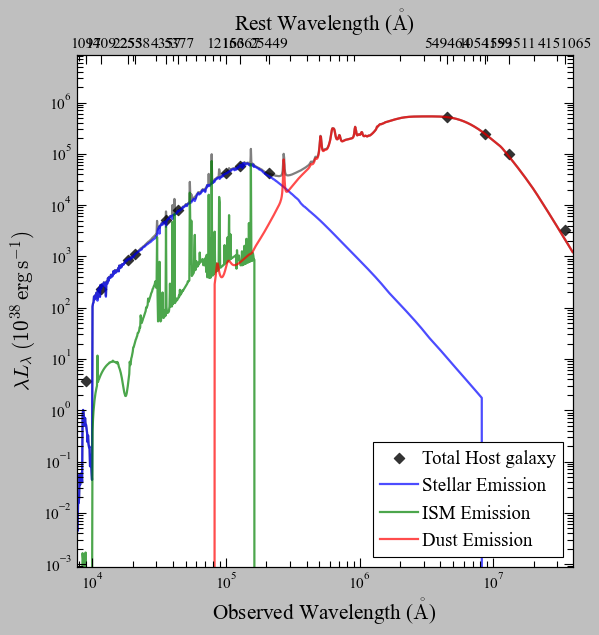

In [10]:

name = 'GNZ7Q'
priorpath = './result/fullfit.prior'
config_file_path='./result/fullfit.lyric'
workplace = './result/full/'

Myfitter,targ,fs = gsutils.read_config_file(config_file_path,workplace,priorpath=priorpath)
smfile = ascii.read(workplace+'{0}.gssummary'.format(name))
for loopx in range(len(smfile)):
    pname = smfile['pname'][loopx]
    if pname in Myfitter.lmParameters:
        Myfitter.lmParameters[pname].set(value=smfile['best_value'][loopx], min=smfile['best_value'][loopx]-0.1,max=smfile['best_value'][loopx]+0.1)
Myfitter.loose_fix_pars()
z = smfile['best_value'][smfile['pname']=='z_host'][0]
cosmo = FlatLambdaCDM(H0=67.8 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.308)
d=cosmo.angular_diameter_distance(z)
dc=d.to(u.cm)
dis=dc.value
scale = d.to(u.kpc).value*np.pi/180/3600




wrange=[0.85,1.15]
pltwave, Sedcomp, Sedlabel, z = Myfitter.cal_model_image()


Bands = ['nircam_f090w','nircam_f115w','nircam_f182m','nircam_f210m','nircam_f356w','nircam_f444w', 
         'miri_f1000w', 'miri_f1280w', 'miri_f2100w','JCMT_450um','JCMT_850um','NOEMA_1mm','NOEMA_3mm']
GS_data = Myfitter.GSdata

waverange = [np.min(pltwave[0]),np.max(pltwave[0])]
wavegrid = np.logspace(np.log10(wrange[0]*waverange[0]),np.log10(wrange[1]*waverange[1]),1000)

fig = plt.figure(figsize=(8,8))
ax = plt.gca()
plt.xlim([wrange[0]*waverange[0],wrange[1]*waverange[1]])

totalx = pltwave[0]

total_model_host = []

sedtot = np.zeros(len(wavegrid))
hostg_labels = ['hosttotal_star','hosttotal_ISM','hosttotal_dust']
hostsed = np.zeros_like(wavegrid)
for loop in range(len(Sedcomp)):
    if Sedlabel[loop] in hostg_labels:
        hostsed += Sedcomp[loop]
        if Sedlabel[loop] == 'hosttotal_star':
            starsed = Sedcomp[loop]
        elif Sedlabel[loop] == 'hosttotal_ISM':
            ISMsed = Sedcomp[loop]
        elif Sedlabel[loop] == 'hosttotal_dust':
            dustsed = Sedcomp[loop]


minsed = np.min(hostsed*wavegrid)
maxsed = np.max(hostsed*wavegrid)
waves = []

for loop in range(len(totalx)):
    im = GS_data.get_image(Bands[loop])
    waves.append(gsutils.effective_wave[Bands[loop]])
    flux =gsutils.get_L_band(wavegrid,hostsed,im.resp)
    total_model_host.append(flux)

hostsed = np.array(hostsed)
wavegrid = np.array(wavegrid)
waves = np.array(waves)
total_model_host = np.array(total_model_host)

plt.plot(wavegrid,wavegrid*hostsed,'k',label='',lw=2,alpha=0.5)
plt.scatter(waves,waves*total_model_host,s=50,c='k',marker='D',label='Total Host galaxy',alpha=0.8,lw=0.5)
# dashline for subcomponents
plt.plot(wavegrid,wavegrid*starsed,'b',label='Stellar Emission',lw=2,alpha=0.7)
plt.plot(wavegrid,wavegrid*ISMsed,'g',label='ISM Emission',lw=2,alpha=0.7)
plt.plot(wavegrid,wavegrid*dustsed,'r',label='Dust Emission',lw=2,alpha=0.7)



plt.xlabel(r'Observed Wavelength ($\mathring{\rm A}$)', fontsize=19)
plt.ylabel(r'$\lambda L_\lambda \; (10^{38} \, \rm erg\,s^{-1})$', fontsize=19)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', length=8, labelsize=14, width=1.)
plt.tick_params(axis='both', which='minor', length=5, labelsize=14, width=1.)
plt.ylim([0.3*minsed,16*maxsed])
# add label for panel (c)
#fig.text(0.16, 0.18, '(c)', fontsize=32, color='k', weight='light', va='top')

plt.xscale('log')
plt.yscale('log')

plt.legend(loc='lower right',fontsize=17,frameon=True,numpoints=1,scatterpoints=1, handletextpad=0.2)
# make a upper x-axis labeled by rest wavelength
ax2 = plt.twiny()
ax2.set_xlim([wrange[0]*waverange[0],wrange[1]*waverange[1]])
ax2.set_xscale('log')
ax2.set_xticks(pltwave[0])
ax2.set_xticklabels(np.array(pltwave[0]/(1.+z),dtype=np.int32))
ax2.set_xlabel(r'Rest Wavelength ($\mathring{\rm A}$)', fontsize=19)
# set ticks label size
ax2.tick_params(axis='both', which='major', length=8, labelsize=14, width=1.)
ax2.tick_params(axis='both', which='minor', length=5, labelsize=14, width=1.)

plt.savefig(workplace+'/sedhost.png',dpi=200,bbox_inches='tight')
plt.show()


INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  1.1387e+21
nircam_f182m band image unit to counts rate is  12.045215
nircam_f182m std 0.006694423966109753
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]


conversion factor is  1.4686e+21
nircam_f210m band image unit to counts rate is  15.534911
nircam_f210m std 0.008475671522319317
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  5.4876145e+22
miri_f1280w band image unit to counts rate is  580.4821
miri_f1280w std 0.43170028924942017
NOEMA_1mm is a photometric point
conversion factor is  1.0
NOEMA_1mm band image unit to counts rate is  1.0578041e-20
mask image not found, use the zero mask image
NOEMA_1mm std 0.0
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  4.2583e+21
nircam_f356w band image unit to counts rate is  45.04447
nircam_f356w std 0.021375644952058792
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  2.7228e+20
nircam_f090w 

Set DATE-AVG to '2025-02-20T14:12:48.347' from MJD-AVG.
Set DATE-END to '2025-02-27T04:32:47.115' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    21.446560 from OBSGEO-[XYZ].
Set OBSGEO-H to 1432517049.518 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-02-19T21:00:11.194' from MJD-AVG.
Set DATE-END to '2025-02-27T04:55:18.538' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    15.777470 from OBSGEO-[XYZ].
Set OBSGEO-H to 1598346142.541 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


conversion factor is  4.4562e+20
nircam_f115w band image unit to counts rate is  4.7137866
nircam_f115w std 0.008355463854968548
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  6.4857e+21
nircam_f444w band image unit to counts rate is  68.606
nircam_f444w std 0.02270454913377762
JCMT_850um is a photometric point
conversion factor is  1.0
JCMT_850um band image unit to counts rate is  1.0578041e-20
mask image not found, use the zero mask image
JCMT_850um std 0.0
NOEMA_3mm is a photometric point
conversion factor is  1.0
NOEMA_3mm band image unit to counts rate is  1.0578041e-20
mask image not found, use the zero mask image
NOEMA_3mm std 0.0


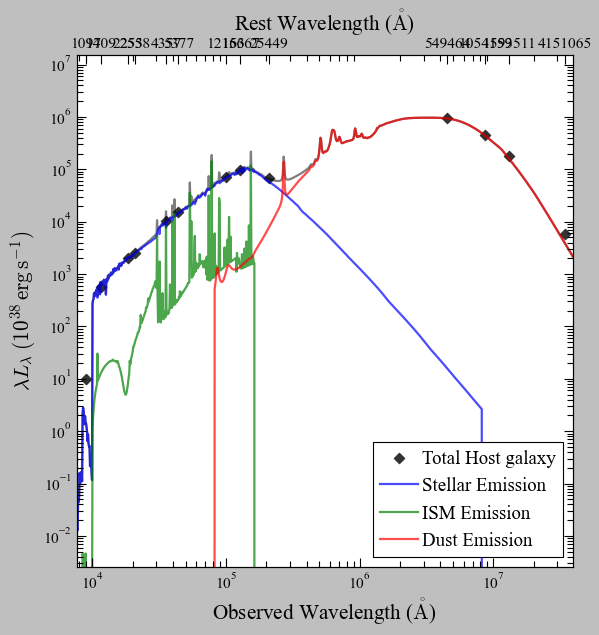

In [11]:

name = 'GNZ7Q'
priorpath = './result/fullfit.prior'
config_file_path='./result/fullfit.lyric'
workplace = './result/full/'

Myfitter,targ,fs = gsutils.read_config_file(config_file_path,workplace,priorpath=priorpath)
smfile = ascii.read(workplace+'{0}.gssummary'.format(name))
for loopx in range(len(smfile)):
    pname = smfile['pname'][loopx]
    if pname in Myfitter.lmParameters:
        Myfitter.lmParameters[pname].set(value=smfile['best_value'][loopx], min=smfile['best_value'][loopx]-0.1,max=smfile['best_value'][loopx]+0.1)
Myfitter.loose_fix_pars()
z = smfile['best_value'][smfile['pname']=='z_host'][0]
cosmo = FlatLambdaCDM(H0=67.8 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.308)
d=cosmo.angular_diameter_distance(z)
dc=d.to(u.cm)
dis=dc.value
scale = d.to(u.kpc).value*np.pi/180/3600




wrange=[0.85,1.15]
pltwave, Sedcomp, Sedlabel, z = Myfitter.cal_model_image()


Bands = ['nircam_f090w','nircam_f115w','nircam_f182m','nircam_f210m','nircam_f356w','nircam_f444w', 
         'miri_f1000w', 'miri_f1280w', 'miri_f2100w','JCMT_450um','JCMT_850um','NOEMA_1mm','NOEMA_3mm']
GS_data = Myfitter.GSdata

waverange = [np.min(pltwave[0]),np.max(pltwave[0])]
wavegrid = np.logspace(np.log10(wrange[0]*waverange[0]),np.log10(wrange[1]*waverange[1]),1000)

fig = plt.figure(figsize=(8,8))
ax = plt.gca()
plt.xlim([wrange[0]*waverange[0],wrange[1]*waverange[1]])

totalx = pltwave[0]

total_model_host = []

sedtot = np.zeros(len(wavegrid))
hostg_labels = ['hostcomp_star','hostcomp_ISM','hostcomp_dust']
hostsed = np.zeros_like(wavegrid)
for loop in range(len(Sedcomp)):
    if Sedlabel[loop] in hostg_labels:
        hostsed += Sedcomp[loop]
        if Sedlabel[loop] == 'hostcomp_star':
            starsed = Sedcomp[loop]
        elif Sedlabel[loop] == 'hostcomp_ISM':
            ISMsed = Sedcomp[loop]
        elif Sedlabel[loop] == 'hostcomp_dust':
            dustsed = Sedcomp[loop]


minsed = np.min(hostsed*wavegrid)
maxsed = np.max(hostsed*wavegrid)
waves = []

for loop in range(len(totalx)):
    im = GS_data.get_image(Bands[loop])
    waves.append(gsutils.effective_wave[Bands[loop]])
    flux =gsutils.get_L_band(wavegrid,hostsed,im.resp)
    total_model_host.append(flux)

hostsed = np.array(hostsed)
wavegrid = np.array(wavegrid)
waves = np.array(waves)
total_model_host = np.array(total_model_host)

plt.plot(wavegrid,wavegrid*hostsed,'k',label='',lw=2,alpha=0.5)
plt.scatter(waves,waves*total_model_host,s=50,c='k',marker='D',label='Total Host galaxy',alpha=0.8,lw=0.5)
# dashline for subcomponents
plt.plot(wavegrid,wavegrid*starsed,'b',label='Stellar Emission',lw=2,alpha=0.7)
plt.plot(wavegrid,wavegrid*ISMsed,'g',label='ISM Emission',lw=2,alpha=0.7)
plt.plot(wavegrid,wavegrid*dustsed,'r',label='Dust Emission',lw=2,alpha=0.7)



plt.xlabel(r'Observed Wavelength ($\mathring{\rm A}$)', fontsize=19)
plt.ylabel(r'$\lambda L_\lambda \; (10^{38} \, \rm erg\,s^{-1})$', fontsize=19)
plt.minorticks_on()
plt.tick_params(axis='both', which='major', length=8, labelsize=14, width=1.)
plt.tick_params(axis='both', which='minor', length=5, labelsize=14, width=1.)
plt.ylim([0.3*minsed,16*maxsed])
# add label for panel (c)
#fig.text(0.16, 0.18, '(c)', fontsize=32, color='k', weight='light', va='top')

plt.xscale('log')
plt.yscale('log')

plt.legend(loc='lower right',fontsize=17,frameon=True,numpoints=1,scatterpoints=1, handletextpad=0.2)
# make a upper x-axis labeled by rest wavelength
ax2 = plt.twiny()
ax2.set_xlim([wrange[0]*waverange[0],wrange[1]*waverange[1]])
ax2.set_xscale('log')
ax2.set_xticks(pltwave[0])
ax2.set_xticklabels(np.array(pltwave[0]/(1.+z),dtype=np.int32))
ax2.set_xlabel(r'Rest Wavelength ($\mathring{\rm A}$)', fontsize=19)
# set ticks label size
ax2.tick_params(axis='both', which='major', length=8, labelsize=14, width=1.)
ax2.tick_params(axis='both', which='minor', length=5, labelsize=14, width=1.)

plt.savefig(workplace+'/sedcomp.png',dpi=200,bbox_inches='tight')
plt.show()


In [12]:
name = 'GNZ7Q'
priorpath = './result/AGNfit.prior'
config_file_path='./result/finalfit.lyric'
workplace = './result/final/'

Myfitter,targ,fs = gsutils.read_config_file(config_file_path,workplace,priorpath=priorpath)
smfile = ascii.read(workplace+'{0}.gssummary'.format(name))
for loopx in range(len(smfile)):
    pname = smfile['pname'][loopx]
    if pname in Myfitter.lmParameters:
        Myfitter.lmParameters[pname].set(value=smfile['best_value'][loopx], min=smfile['best_value'][loopx]-0.1,max=smfile['best_value'][loopx]+0.1)
Myfitter.loose_fix_pars()
logM = smfile['best_value'][smfile['pname']=='logM_total'][0]
re = smfile['best_value'][smfile['pname']=='total_Re'][0]
n = smfile['best_value'][smfile['pname']=='total_n'][0]
z = smfile['best_value'][smfile['pname']=='z_host'][0]

jwstbands = ['nircam_f090w','nircam_f115w','nircam_f182m','nircam_f210m','nircam_f356w','nircam_f444w', 
         'miri_f1000w', 'miri_f1280w', 'miri_f2100w']
datapath = '/home/liruancun/Works/JWST/seiji/NSED'

for loop in range(len(jwstbands)):
    lname = 'AGN_{0}_logL'.format(jwstbands[loop])
    wave_obs = gsutils.effective_wave[jwstbands[loop]]
    wave_rest = np.array(wave_obs/(1+z))



    logL = smfile['best_value'][smfile['pname']==lname][0]
    L38 = np.array(10**(logL-38))
    logL38_err = 0.01
    #print (logL38_err)
    L38_err = L38*logL38_err*np.log(10)
   

    outputname = '{0}/AGN_{1}.fits'.format(datapath,jwstbands[loop])
    gsutils.photometry_to_img(jwstbands[loop], L38, 0.05*L38, z, outputname, unit = 'L38')

INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  1.1387e+21
nircam_f182m band image unit to counts rate is  12.045215
nircam_f182m std 0.006694423966109753
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  4.4562e+20
nircam_f115w band image unit to counts rate is  4.7137866
nircam_f115w std 0.008355463854968548
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  6.4857e+21
nircam_f444w band image unit to counts rate is  68.606
nircam_f444w std 0.02270454913377762
INFO: using the unit cR passed to the FITS reader instead of the unit 10.0*nanoJansky in the FITS file. [astropy.nddata.ccddata]
conversion factor is  2.7228e+20
nircam_f090w band image unit to counts rate is  2.880189
nircam_f090

Set DATE-AVG to '2025-02-19T21:00:11.194' from MJD-AVG.
Set DATE-END to '2025-02-27T04:55:18.538' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    15.777470 from OBSGEO-[XYZ].
Set OBSGEO-H to 1598346142.541 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-02-20T14:12:48.347' from MJD-AVG.
Set DATE-END to '2025-02-27T04:32:47.115' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    21.446560 from OBSGEO-[XYZ].
Set OBSGEO-H to 1432517049.518 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


conversion factor is  4.2583e+21
nircam_f356w band image unit to counts rate is  45.04447
nircam_f356w std 0.021375644952058792
No energy balances assigned
